# 📊 Análise de Performance SuperStore
### Projeto 2 · Rota 2 · Laboratoria — Python & Agentes de IA

**Analista:** Lívia Marcilio Lopes

**Nota sobre os comentários deste notebook:** os comentários em código aqui não explicam sintaxe básica de Python/pandas — assumo que quem está lendo já tem conhecimento prévio de análise de dados. Eles são usados apenas quando carregam uma decisão relevante: por que tratei um dado de um jeito e não de outro, ou o que uma escolha técnica significa para a análise de negócio.

---
## Meta 1 — Importar as tabelas no Google Colab

Objetivo: carregar `order.csv` e `shipping.csv` em DataFrames distintos e confirmar que a leitura preservou colunas e tipos coerentes antes de qualquer tratamento.

In [1]:
import pandas as pd

**Upload dos arquivos no Colab:** suba os dois CSVs pelo painel lateral (ícone de pasta → *upload*),
ou rode a célula abaixo para fazer o upload via diálogo do navegador.
Depois do upload, os arquivos ficam disponíveis pelo nome no diretório atual do Colab — por isso o
`pd.read_csv()` da próxima célula usa só o nome do arquivo, sem caminho de pasta.

In [2]:
# Upload interativo — descomente se estiver rodando no Colab e ainda não tiver subido os arquivos
# from google.colab import files
# files.upload()

In [3]:
# order_id sozinho se repete (um pedido pode ter vários itens/produtos) — isso é esperado,
# não é erro de leitura. A chave real de cada linha é (order_id + product_id), como confirmado
# na descrição das bases do case.
df_order = pd.read_csv('superstore_order.csv')
df_shipping = pd.read_csv('superstore_shipping.csv')

### Conferência inicial — `order`

In [4]:
df_order.head()

,category,city,customer_ID,customer_name,discount,order_id,order_priority,product_id,product_name,profit,quantity,segment,order_date,Sales,country
0,Office Supplies,Aba,DW-34801,Dianna Wilson,0.70,NI-2011-6340,Medium,OFF-BOS-10001348,"Boston Pencil Sharpener, Water Color",-90.174,14,Home Office,2023-04-16 00:00:00.000000 UTC,NaN,Nigeria
1,Office Supplies,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,OFF-AR-10002382,"Binney & Smith Pencil Sharpener, Water Color",49.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,108.0,Italy
2,Furniture,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,FUR-FU-10004640,"Tenex Light Bulb, Durable",7.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,64.0,Italy
3,Office Supplies,Pescara,RH-195102,Rick Huthwaite,0.40,ES-2011-1702658,Medium,OFF-ST-10001974,"Rogers File Cart, Industrial",-32.580,1,Home Office,2023-09-30 00:00:00.000000 UTC,85.0,Italy
4,Office Supplies,Banda Aceh,MF-176651,Maureen Fritzler,0.27,ID-2011-49031,Medium,OFF-AR-10004138,"Stanley Pens, Easy-Erase",4.068,5,Corporate,2023-03-25 00:00:00.000000 UTC,38.0,Indonesia


In [5]:
df_order.info()

<class 'pandas.DataFrame'>
RangeIndex: 19960 entries, 0 to 19959
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        19960 non-null  str    
 1   city            19960 non-null  str    
 2   customer_ID     19960 non-null  str    
 3   customer_name   19960 non-null  str    
 4   discount        19960 non-null  float64
 5   order_id        19960 non-null  str    
 6   order_priority  19960 non-null  str    
 7   product_id      19960 non-null  str    
 8   product_name    19960 non-null  str    
 9   profit          19960 non-null  float64
 10  quantity        19960 non-null  int64  
 11  segment         19960 non-null  str    
 12  order_date      19960 non-null  str    
 13  Sales           19938 non-null  float64
 14  country         19960 non-null  str    
dtypes: float64(3), int64(1), str(11)
memory usage: 2.3 MB


### Conferência inicial — `shipping`

In [6]:
df_shipping.head()

,order_id,product_id,ship_mode,shipping_cost,ship_date
0,MX-2011-109029,OFF-BI-10004491,First Class,3.365,2023-07-21 00:00:00.000000 UTC
1,QA-2011-3520,OFF-SAN-10004881,First Class,34.360,2023-05-08 00:00:00.000000 UTC
2,QA-2011-3520,OFF-STA-10002654,First Class,4.430,2023-05-08 00:00:00.000000 UTC
3,EG-2011-7860,OFF-ROG-10002279,First Class,5.450,2023-11-06 00:00:00.000000 UTC
4,EG-2011-7860,TEC-NOK-10003341,First Class,5.810,2023-11-06 00:00:00.000000 UTC


In [7]:
df_shipping.info()

<class 'pandas.DataFrame'>
RangeIndex: 19960 entries, 0 to 19959
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       19960 non-null  str    
 1   product_id     19960 non-null  str    
 2   ship_mode      19960 non-null  str    
 3   shipping_cost  19960 non-null  float64
 4   ship_date      19960 non-null  str    
dtypes: float64(1), str(4)
memory usage: 779.8 KB


**Leitura rápida do `.info()`:**
- `order` carregou com 15 colunas e o tipo de `Sales` já veio como `float64` mesmo com valores nulos
  (pandas infere `float` quando há `NaN` numérico misturado — é esperado, não um problema de leitura).
- `shipping` carregou com 5 colunas, sem nenhum nulo aparente pelo `.info()`.
- `order_date` e `ship_date` vieram como `object` (texto), não como data — ponto para tratar na Meta 2,
  não agora: a Meta 1 só confirma que a estrutura de colunas está correta, a conversão de tipo é
  decisão de limpeza.

---
## Dicionário de dados (atividade opcional)

Documentar o significado de cada coluna agora evita ambiguidade mais adiante — por exemplo,
saber de antemão que `order_id` **não é único** por linha evita que alguém trate isso como
"duplicata" na Meta 2 sem entender o motivo.

In [8]:
dicionario_order = pd.DataFrame([
    ("order_id", "Identificador do pedido. NÃO é único por linha: um pedido pode ter vários produtos."),
    ("product_id", "Identificador único do produto. Junto com order_id forma a chave real de cada linha."),
    ("category", "Categoria do produto vendido (Office Supplies, Furniture, Technology)."),
    ("product_name", "Nome descritivo do produto."),
    ("customer_ID", "Identificador único do cliente."),
    ("customer_name", "Nome do cliente que fez o pedido."),
    ("segment", "Segmento do cliente: Consumer, Corporate ou Home Office."),
    ("city", "Cidade onde o pedido foi feito."),
    ("country", "País onde o pedido foi feito."),
    ("order_date", "Data em que o pedido foi realizado."),
    ("order_priority", "Prioridade do pedido: Low, Medium, High, Critical."),
    ("discount", "Percentual de desconto aplicado ao pedido (0.0 a 1.0)."),
    ("quantity", "Quantidade de unidades do produto no pedido."),
    ("Sales", "Valor total de vendas do produto naquele pedido."),
    ("profit", "Lucro gerado pelo pedido (pode ser negativo)."),
], columns=["coluna", "descricao"])

dicionario_shipping = pd.DataFrame([
    ("order_id", "Identificador do pedido — mesma chave usada em order."),
    ("product_id", "Identificador do produto — mesma chave usada em order."),
    ("ship_mode", "Modo de envio: First Class, Same Day, Second Class, Standard Class."),
    ("shipping_cost", "Custo de envio do pedido."),
    ("ship_date", "Data em que o pedido foi enviado."),
], columns=["coluna", "descricao"])

print("Dicionário — order")
display(dicionario_order)
print("\nDicionário — shipping")
display(dicionario_shipping)

Dicionário — order


,coluna,descricao
0,order_id,Identificador do pedido. NÃO é único por linha...
1,product_id,Identificador único do produto. Junto com orde...
2,category,"Categoria do produto vendido (Office Supplies,..."
3,product_name,Nome descritivo do produto.
4,customer_ID,Identificador único do cliente.
5,customer_name,Nome do cliente que fez o pedido.
6,segment,"Segmento do cliente: Consumer, Corporate ou Ho..."
7,city,Cidade onde o pedido foi feito.
8,country,País onde o pedido foi feito.
9,order_date,Data em que o pedido foi realizado.



Dicionário — shipping


,coluna,descricao
0,order_id,Identificador do pedido — mesma chave usada em...
1,product_id,Identificador do produto — mesma chave usada e...
2,ship_mode,"Modo de envio: First Class, Same Day, Second C..."
3,shipping_cost,Custo de envio do pedido.
4,ship_date,Data em que o pedido foi enviado.


---
✅ **Checklist da Meta 1**
- [x] Tabelas `order` e `shipping` carregadas em DataFrames distintos
- [x] `.head()` conferido nas duas — colunas vieram como esperado
- [x] `.info()` conferido — tipos coerentes, com uma pendência já mapeada (`order_date`/`ship_date` como texto, tratar na Meta 2)
- [x] Dicionário de dados documentado (atividade opcional)

Próximo passo: **Meta 2 — tratar nulos e duplicados**, usando as decisões já discutidas na Ficha Técnica.

---
## Meta 2 — Identificar valores nulos

Objetivo: auditar `order` e `shipping` coluna a coluna, ver onde os nulos se concentram, e decidir
o que fazer com eles olhando para o impacto na pergunta de negócio — não só para o número em si.

In [9]:
print("Nulos em order:")
print(df_order.isnull().sum())
print("\nNulos em shipping:")
print(df_shipping.isnull().sum())

Nulos em order:
category           0
city               0
customer_ID        0
customer_name      0
discount           0
order_id           0
order_priority     0
product_id         0
product_name       0
profit             0
quantity           0
segment            0
order_date         0
Sales             22
country            0
dtype: int64

Nulos em shipping:
order_id         0
product_id       0
ship_mode        0
shipping_cost    0
ship_date        0
dtype: int64


In [10]:
# Isolando as linhas para entender o padrão: será que quem tem Sales nulo também
# perdeu outras informações da linha, ou é só essa coluna que falhou?
linhas_nulas = df_order[df_order['Sales'].isnull()]
linhas_nulas[['order_id', 'product_id', 'category', 'quantity', 'profit']]

,order_id,product_id,category,quantity,profit
0,NI-2011-6340,OFF-BOS-10001348,Office Supplies,14,-90.1740
1950,SG-2011-8430,OFF-TEN-10004194,Office Supplies,1,63.2400
2186,IT-2011-1152860,OFF-ST-10003153,Office Supplies,2,-8.1300
2273,ES-2011-3002504,OFF-ST-10003153,Office Supplies,1,63.2400
4085,IR-2011-6620,OFF-TEN-10004194,Office Supplies,1,63.2400
4129,CG-2011-6250,OFF-TEN-10004194,Office Supplies,1,63.2400
5147,ID-2011-12596,OFF-ST-10002066,Office Supplies,2,-45.9018
5366,ID-2011-23215,FUR-CH-10002932,Furniture,1,-0.0180
6712,IN-2011-12967,OFF-AP-10002128,Office Supplies,3,22.4100
7781,IN-2011-54155,TEC-MA-10002471,Technology,2,53.4894


In [11]:
print("Nulos de profit entre essas 22 linhas:", linhas_nulas['profit'].isnull().sum())
print("\nDistribuição por categoria:")
print(linhas_nulas['category'].value_counts())

Nulos de profit entre essas 22 linhas: 0

Distribuição por categoria:
category
Office Supplies    15
Furniture           4
Technology          3
Name: count, dtype: int64


**Minha decisão, e por quê:**

`shipping` não tem nenhum nulo — auditoria fechada, nada a tratar ali. `order` tem 22 linhas com `Sales`
vazio, e é isso que precisa de uma decisão de verdade, não só de um comando.

Primeiro fui ver se esses 22 casos eram "linhas quebradas" de forma geral, ou se era só a coluna `Sales`
que falhou. E é só ela: `profit` e `quantity` vieram preenchidos certinho em todas as 22. Isso muda a
decisão — se a linha inteira estivesse capenga, eu cogitaria descartar. Mas aqui tem informação boa
demais pra jogar fora: descartar a linha por causa de uma coluna vazia significaria perder profit e
quantity válidos, e isso enviesaria justamente a pergunta de negócio sobre lucratividade que estou
tentando responder.

Também olhei se os nulos se concentravam numa categoria específica, o que sugeriria uma falha
sistemática de um processo — por exemplo, um formulário de uma categoria que não captura o preço
corretamente. Não é o caso: a distribuição (15 Office Supplies, 4 Furniture, 3 Technology) segue mais
ou menos a proporção geral das categorias na base. Isso me deixa mais confortável em tratar como falha
pontual de registro, não como um problema estrutural que precisa virar um insight à parte.

**Decisão:** vou manter as 22 linhas na base — elas continuam válidas para qualquer análise que use
`profit`, `quantity`, `discount`, `category`, `segment` etc. Não vou inventar um valor de `Sales` via
imputação (média ou mediana), porque não tenho como confirmar que o valor imputado remeteria à venda
real daquele pedido, e isso poderia distorcer qualquer métrica que dependa diretamente de `Sales`, como
receita total ou ticket médio. Nas análises específicas que dependem de `Sales`, vou excluir só essas
22 linhas na hora do cálculo — não da base inteira. É pouco volume (0,11% de `order`), então o impacto
de excluir apenas ali é desprezível, e é mais honesto do que fingir que sei um número que não tenho.

---
## Meta 3 — Identificar valores duplicados

Objetivo: descobrir se a duplicidade é erro de registro ou é a complexidade natural de um pedido
com vários produtos — e só decidir remover depois de entender qual dos dois casos é.

In [12]:
print("order — duplicados na linha inteira:", df_order.duplicated().sum())
print("order — duplicados por chave (order_id + product_id):", df_order.duplicated(subset=['order_id', 'product_id']).sum())
print("\nshipping — duplicados na linha inteira:", df_shipping.duplicated().sum())
print("shipping — duplicados por chave (order_id + product_id):", df_shipping.duplicated(subset=['order_id', 'product_id']).sum())

order — duplicados na linha inteira: 5
order — duplicados por chave (order_id + product_id): 16

shipping — duplicados na linha inteira: 0
shipping — duplicados por chave (order_id + product_id): 16


In [13]:
# keep=False traz as duas ocorrências de cada duplicata, não só a repetição — preciso ver o par
# inteiro para decidir se é erro ou dado legítimo.
duplicatas_totais_order = df_order[df_order.duplicated(keep=False)]
duplicatas_totais_order.sort_values(['order_id', 'product_id'])

,category,city,customer_ID,customer_name,discount,order_id,order_priority,product_id,product_name,profit,quantity,segment,order_date,Sales,country
9441,Office Supplies,Mechelen,RF-198402,Roy Französisch,0.00,ES-2012-2740636,Medium,OFF-AR-10004884,"Sanford Pens, Fluorescent",10.3500,3,Consumer,2024-08-29 00:00:00.000000 UTC,37.0,Belgium
9442,Office Supplies,Mechelen,RF-198402,Roy Französisch,0.00,ES-2012-2740636,Medium,OFF-AR-10004884,"Sanford Pens, Fluorescent",10.3500,3,Consumer,2024-08-29 00:00:00.000000 UTC,37.0,Belgium
5393,Office Supplies,Armidale,AR-105101,Andrew Roberts,0.10,ID-2011-54176,Medium,OFF-BI-10000168,"Cardinal Hole Reinforcements, Recycled",2.5200,3,Consumer,2023-05-03 00:00:00.000000 UTC,15.0,Australia
5394,Office Supplies,Armidale,AR-105101,Andrew Roberts,0.10,ID-2011-54176,Medium,OFF-BI-10000168,"Cardinal Hole Reinforcements, Recycled",2.5200,3,Consumer,2023-05-03 00:00:00.000000 UTC,15.0,Australia
10004,Furniture,Bangkok,RM-193751,Raymond Messe,0.27,IN-2012-38657,Medium,FUR-CH-10002510,"Office Star Steel Folding Chair, Adjustable",89.4300,5,Consumer,2024-11-05 00:00:00.000000 UTC,344.0,Thailand
10005,Furniture,Bangkok,RM-193751,Raymond Messe,0.27,IN-2012-38657,Medium,FUR-CH-10002510,"Office Star Steel Folding Chair, Adjustable",89.4300,5,Consumer,2024-11-05 00:00:00.000000 UTC,344.0,Thailand
16392,Furniture,Rancagua,LS-172003,Luke Schmidt,0.00,MX-2012-137561,Medium,FUR-CH-10000892,"SAFCO Executive Leather Armchair, Red",12.2800,2,Corporate,2024-12-03 00:00:00.000000 UTC,615.0,Chile
16393,Furniture,Rancagua,LS-172003,Luke Schmidt,0.00,MX-2012-137561,Medium,FUR-CH-10000892,"SAFCO Executive Leather Armchair, Red",12.2800,2,Corporate,2024-12-03 00:00:00.000000 UTC,615.0,Chile
5966,Furniture,Columbus,LB-167954,Laurel Beltran,0.30,US-2011-150119,Medium,FUR-CH-10002965,Global Leather Highback Executive Chair with P...,-12.0588,2,Home Office,2023-04-23 00:00:00.000000 UTC,281.0,United States
5967,Furniture,Columbus,LB-167954,Laurel Beltran,0.30,US-2011-150119,Medium,FUR-CH-10002965,Global Leather Highback Executive Chair with P...,-12.0588,2,Home Office,2023-04-23 00:00:00.000000 UTC,281.0,United States


In [14]:
# Separando as duplicatas de CHAVE que NÃO são duplicatas de linha inteira — ou seja, mesmo
# order_id + product_id, mas com profit/quantity/Sales diferentes. Essas são candidatas a
# "linha múltipla legítima", não erro.
chaves_full = set(map(tuple, duplicatas_totais_order[['order_id', 'product_id']].values))
duplicatas_chave_order = df_order[df_order.duplicated(subset=['order_id', 'product_id'], keep=False)]
duplicatas_legitimas = duplicatas_chave_order[
    ~duplicatas_chave_order[['order_id', 'product_id']].apply(tuple, axis=1).isin(chaves_full)
]
duplicatas_legitimas.sort_values(['order_id', 'product_id'])[
    ['order_id', 'product_id', 'category', 'quantity', 'profit', 'Sales']
]

,order_id,product_id,category,quantity,profit,Sales
14051,CA-2012-103135,OFF-BI-10000069,Office Supplies,9,62.1414,NaN
14052,CA-2012-103135,OFF-BI-10000069,Office Supplies,6,41.4276,90.0
16125,ES-2012-3945862,OFF-AR-10003066,Office Supplies,2,4.7400,53.0
18015,ES-2012-3945862,OFF-AR-10003066,Office Supplies,5,11.8500,132.0
16581,ES-2012-4293573,OFF-ST-10000580,Office Supplies,3,41.5800,174.0
16582,ES-2012-4293573,OFF-ST-10000580,Office Supplies,2,27.7200,116.0
12075,ES-2012-5238758,OFF-AR-10000399,Office Supplies,8,143.1600,379.0
12076,ES-2012-5238758,OFF-AR-10000399,Office Supplies,7,125.2650,332.0
3189,ID-2011-43977,OFF-BI-10000340,Office Supplies,4,-13.5240,160.0
3190,ID-2011-43977,OFF-BI-10000340,Office Supplies,2,-6.7620,80.0


In [15]:
# Cruzando com shipping: as mesmas 16 chaves duplicadas de order também duplicam em shipping?
chaves_dupe_order = set(map(tuple, df_order[df_order.duplicated(subset=['order_id','product_id'], keep=False)][['order_id','product_id']].drop_duplicates().values))
chaves_dupe_ship = set(map(tuple, df_shipping[df_shipping.duplicated(subset=['order_id','product_id'], keep=False)][['order_id','product_id']].drop_duplicates().values))
print("chaves duplicadas em order:", len(chaves_dupe_order))
print("chaves duplicadas em shipping:", len(chaves_dupe_ship))
print("são exatamente as mesmas chaves nas duas tabelas?", chaves_dupe_order == chaves_dupe_ship)

# E, especificamente para as 5 chaves 100% duplicadas em order, o shipping também repete
# a linha inteira, ou os registros de envio são diferentes entre si?
identicas_no_shipping = 0
for chave in chaves_full:
    par = df_shipping[(df_shipping['order_id'] == chave[0]) & (df_shipping['product_id'] == chave[1])]
    identicas_no_shipping += par.duplicated().sum()
print("Das 5 chaves 100% duplicadas em order, quantas têm linha de shipping também 100% idêntica?", identicas_no_shipping, "de 5")

chaves duplicadas em order: 16
chaves duplicadas em shipping: 16
são exatamente as mesmas chaves nas duas tabelas? True


Das 5 chaves 100% duplicadas em order, quantas têm linha de shipping também 100% idêntica? 0 de 5


**Minha decisão, e por quê:**

Encontrei duas coisas bem diferentes escondidas atrás do mesmo comando `.duplicated()`, e tratá-las
igual seria um erro.

**As 11 chaves com dado diferente são legítimas.** São casos como o pedido `IN-2011-77892`, produto
`TEC-PH-10001751`, que aparece duas vezes com profit e Sales bem diferentes entre si (460.08 vs
1150.20). Isso é exatamente o que o case avisou: um mesmo produto pode entrar mais de uma vez no
mesmo pedido, em lançamentos separados. Remover essas linhas destruiria informação real sobre o
pedido. Decisão: manter todas.

**As 5 chaves 100% idênticas em `order` (todas as 15 colunas iguais, incluindo profit e Sales) são
outra história.** É estatisticamente muito improvável que duas linhas de pedido reais tenham valor
idêntico em 15 colunas por coincidência — isso tem cara de erro de registro (por exemplo, o mesmo
lançamento submetido duas vezes no sistema). Mas antes de simplesmente remover, fui checar o lado do
shipping para essas mesmas 5 chaves — e nenhuma delas tem duas linhas idênticas em `shipping`, os dois
registros de envio sempre diferem em algo (custo ou data). Isso não invalida a hipótese de duplicidade:
é coerente com um pedido lançado duas vezes no sistema gerando dois envios físicos reais e distintos,
cada um com seu próprio custo/data de despacho. Ou seja, o problema está na camada de pedido, não na
de logística.

**Decisão:** vou remover a linha extra das 5 chaves 100% duplicadas em `order` com
`drop_duplicates()` (mantendo a primeira ocorrência), porque contá-las duas vezes infla
artificialmente contagem de pedidos, `Sales` e `profit` — e é exatamente o tipo de distorção que a
Ana e o Diego citaram na reunião como motivo para não confiarem nos números atuais. Não vou mexer em
`shipping` agora: como as duas linhas de envio para essas chaves são diferentes entre si, decidir o
que fazer com elas (manter as duas, somar o custo, ficar só com a primeira) é uma decisão de **merge**
— vou revisitar isso explicitamente na Meta 6, quando as tabelas forem unidas, para não perder o
rastro dessa questão em aberto.

In [16]:
# Removendo apenas as duplicatas 100% idênticas (linha inteira), mantendo a primeira ocorrência.
# As duplicatas de chave com dados diferentes NÃO são tocadas aqui — são pedidos legítimos.
linhas_antes = len(df_order)
df_order = df_order.drop_duplicates(keep='first').reset_index(drop=True)
linhas_depois = len(df_order)
print(f"Linhas removidas: {linhas_antes - linhas_depois}")
print(f"Total de linhas em order após a limpeza de duplicados: {linhas_depois}")

Linhas removidas: 5
Total de linhas em order após a limpeza de duplicados: 19955


---
## Meta 4 — Valores atípicos em variáveis categóricas (opcional)

Objetivo: usar `.unique()` para procurar variação de escrita nas colunas de texto, e só padronizar
o que, de fato, representa a mesma entidade real — sem unir categorias que só parecem iguais.

In [17]:
print("category:", df_order['category'].unique())
print("\nsegment:", df_order['segment'].unique())
print("\norder_priority:", df_order['order_priority'].unique())
print("\nship_mode:", df_shipping['ship_mode'].unique())
print("\ncity — nº de valores únicos:", df_order['city'].nunique())
print("country — nº de valores únicos:", df_order['country'].nunique())

category: <StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str

segment: <StringArray>
['Home Office', 'Corporate', 'Consumer']
Length: 3, dtype: str

order_priority: <StringArray>
['Medium', 'High', 'Low', 'Critical']
Length: 4, dtype: str



ship_mode: <StringArray>
['First Class', 'Same Day', 'Second Class', 'Standard Class']
Length: 4, dtype: str

city — nº de valores únicos: 2592
country — nº de valores únicos: 143


In [18]:
# strip() em todas as categóricas de texto, mesmo sem indício de espaço sobrando —
# é barato de fazer e evita bug silencioso de espaço invisível no futuro.
colunas_texto_order = ['category', 'segment', 'order_priority', 'city', 'country']
for coluna in colunas_texto_order:
    df_order[coluna] = df_order[coluna].str.strip()

df_shipping['ship_mode'] = df_shipping['ship_mode'].str.strip()

print("category segue com", df_order['category'].nunique(), "categorias após o strip")
print("segment segue com", df_order['segment'].nunique(), "categorias após o strip")
print("order_priority segue com", df_order['order_priority'].nunique(), "categorias após o strip")
print("ship_mode segue com", df_shipping['ship_mode'].nunique(), "categorias após o strip")

category segue com 3 categorias após o strip
segment segue com 3 categorias após o strip
order_priority segue com 4 categorias após o strip
ship_mode segue com 4 categorias após o strip


`category`, `segment`, `order_priority` e `ship_mode` vieram limpos — sem variação de acento,
caixa ou espaço, e o `strip()` não mudou a contagem de categorias em nenhuma delas. `city` tem 2.592
valores únicos, o que é esperado para uma base global (não dá pra auditar por olho, então fui direto
procurar inconsistência em `country`, que tem só 143 valores — mais fácil de inspecionar por completo.

In [19]:
sorted(df_order['country'].unique().tolist())

['Afghanistan',
 'Albania',
 'Algeria',
 'Angola',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'BR',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Benin',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Brazil',
 'Bulgaria',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Central African Republic',
 'Chile',
 'China',
 'Colombia',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Estonia',
 'Ethiopia',
 'Finland',
 'France',
 'Gabon',
 'Georgia',
 'Germany',
 'Ghana',
 'Guadeloupe',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Haiti',
 'Honduras',
 'Hong Kong',
 'Hungary',
 'India',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kenya',
 'Kyrgyzstan',
 'Lebanon',
 'Lesotho',
 'Liberia',
 'Libya',
 'Lithuania',
 'MX',
 'Macedonia',
 'Madagascar',
 'Malaysia',
 '

In [20]:
# 'BR' e 'MX' destoam do resto da coluna, que usa nome completo do país (Brazil, Mexico, etc).
# Antes de já sair substituindo 'BR' por 'Brazil', preciso confirmar se as cidades dessas linhas
# realmente são cidades brasileiras/mexicanas — só assim garanto que é a mesma entidade real.
print("Linhas com country == 'BR':", (df_order['country'] == 'BR').sum())
print(df_order[df_order['country'] == 'BR'][['order_id', 'city', 'country']].drop_duplicates(subset='city'))

print("\nLinhas com country == 'MX':", (df_order['country'] == 'MX').sum())
print(df_order[df_order['country'] == 'MX'][['order_id', 'city', 'country']].drop_duplicates(subset='city'))

Linhas com country == 'BR': 13
             order_id             city country
7      MX-2011-109029  Cruzeiro do Sul      BR
1788   MX-2011-153871          Torreón      BR
2099   MX-2011-169467     Azcapotzalco      BR
2814   MX-2011-130148           Bayamo      BR
11136  MX-2012-115056       Chinandega      BR
17792  MX-2012-137148        Santa Ana      BR

Linhas com country == 'MX': 3
             order_id                   city country
15042  MX-2012-154970  San José de las Lajas      MX
19306  MX-2012-150133      San Andrés Tuxtla      MX


**Minha decisão, e por quê:**

Esse foi o alerta do próprio coach se confirmando na prática: `BR` e `MX` parecem, à primeira vista,
só abreviações de `Brazil` e `Mexico` — o tipo de coisa que um `.replace()` rápido resolveria. Mas
antes de unir, fui checar as cidades dessas linhas, e elas **não batem**: `BR` aparece em cidades como
Torreón (México), Azcapotzalco (bairro da Cidade do México), Bayamo (Cuba) e Chinandega (Nicarágua) —
só uma das linhas (Cruzeiro do Sul) é de fato uma cidade brasileira. O mesmo acontece com `MX`: uma das
três linhas tem cidade em Cuba, não no México.

Se eu tivesse simplesmente trocado `'BR'` por `'Brazil'`, teria inventado o país errado para a maior
parte dessas linhas — exatamente o erro que o Oráculo avisou pra não cometer: unir categorias que só
parecem a mesma entidade, sem validar. `city` e `country` estão inconsistentes entre si nessas 16
linhas, e não tenho como saber, só com os dados que tenho, qual das duas colunas está certa.

**Decisão:** não vou fazer `replace('BR', 'Brazil')` nem `replace('MX', 'Mexico')`. Vou tratar `BR` e
`MX` como valores inválidos em `country` — convertendo para nulo (`NaN`) — porque não são a mesma
entidade real das cidades associadas, e mantê-los como estão distorceria qualquer análise agrupada por
país. As linhas continuam na base (não vou descartá-las: `city`, `profit`, `discount` etc. seguem
válidos), só o valor de `country` fica sinalizado como "a resolver" para quem for usar essa coluna
especificamente. Isso é um novo nulo que passa a existir *depois* da Meta 4 — vale deixar claro na
Ficha Técnica pra não parecer inconsistente com a contagem da Meta 2.

In [21]:
import numpy as np

linhas_afetadas = df_order['country'].isin(['BR', 'MX']).sum()
df_order['country'] = df_order['country'].replace({'BR': np.nan, 'MX': np.nan})

print(f"Linhas marcadas como country nulo (antes eram 'BR'/'MX'): {linhas_afetadas}")
print(f"Total de nulos em country agora: {df_order['country'].isnull().sum()}")
print(f"country segue com {df_order['country'].nunique()} valores únicos válidos")

Linhas marcadas como country nulo (antes eram 'BR'/'MX'): 16
Total de nulos em country agora: 16
country segue com 141 valores únicos válidos


### Revisão da decisão: dá pra recuperar o país certo em vez de deixar nulo?

Antes de aceitar o nulo como decisão final, vale investigar se dá pra confirmar o país real de cada
cidade com uma fonte externa confiável — em vez de simplesmente presumir. Se a evidência for sólida,
usar o nulo seria jogar fora uma informação que eu já tinha condição de recuperar.

In [22]:
!pip install geonamescache -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [23]:
import geonamescache
import unicodedata

gc = geonamescache.GeonamesCache()
cities_db = gc.get_cities()
countries_db = gc.get_countries()

def remover_acentos(texto):
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

def paises_possiveis(nome_cidade):
    """Retorna todos os países que têm uma cidade com esse nome na base geonamescache,
    ordenados por população (a cidade mais populosa primeiro)."""
    alvo = remover_acentos(nome_cidade).lower()
    encontrados = []
    for info in cities_db.values():
        if remover_acentos(info['name']).lower() == alvo:
            pais = countries_db.get(info['countrycode'], {}).get('name', info['countrycode'])
            encontrados.append((pais, info['population']))
    return sorted(encontrados, key=lambda x: -x[1])

cidades_a_resolver = df_order.loc[df_order['country'].isnull(), 'city'].unique()
for cidade in cidades_a_resolver:
    print(f"{cidade}: {paises_possiveis(cidade)}")

Cruzeiro do Sul: [('Brazil', 91888)]
Torreón: [('Mexico', 735340)]
Azcapotzalco: [('Mexico', 414711)]
Bayamo: [('Cuba', 192632)]
Chinandega: [('Nicaragua', 126387)]


San José de las Lajas: [('Cuba', 54847)]
Santa Ana: [('United States', 310227), ('El Salvador', 176661), ('Philippines', 47158), ('Venezuela', 35452), ('Peru', 25145), ('Venezuela', 19215)]
San Andrés Tuxtla: [('Mexico', 61769)]


**Resultado da checagem:** 7 das 8 cidades têm **exatamente um** país correspondente na base — ou
seja, evidência sólida o bastante pra corrigir com confiança. A exceção é `Santa Ana`, que existe como
cidade em pelo menos 6 países diferentes (Estados Unidos, El Salvador, Filipinas, Venezuela — duas
vezes — e Peru), sem nenhum outro dado na minha base (estado, CEP, coordenada) que desempate qual é a
certa. Aqui a decisão muda: para as 7 cidades inequívocas, corrijo o país. Para `Santa Ana`, mantenho
o nulo — porque "existe uma correspondência" não é o mesmo que "existe uma correspondência confiável
o bastante para eu afirmar como fato" .

In [24]:
# Mapeamento construído a partir da checagem acima — só entram cidades com país inequívoco.
mapa_cidade_pais = {
    'Cruzeiro do Sul': 'Brazil',
    'Torreón': 'Mexico',
    'Azcapotzalco': 'Mexico',
    'Bayamo': 'Cuba',
    'Chinandega': 'Nicaragua',
    'San José de las Lajas': 'Cuba',
    'San Andrés Tuxtla': 'Mexico',
    # 'Santa Ana' fica de fora de propósito: ambíguo, permanece nulo
}

linhas_corrigidas = df_order['city'].map(mapa_cidade_pais).notna() & df_order['country'].isnull()
df_order.loc[linhas_corrigidas, 'country'] = df_order.loc[linhas_corrigidas, 'city'].map(mapa_cidade_pais)

print(f"Linhas corrigidas com país recuperado: {linhas_corrigidas.sum()} de 16")
print(f"Nulos restantes em country: {df_order['country'].isnull().sum()} (Santa Ana, ambígua)")
print(f"country agora tem {df_order['country'].nunique()} valores únicos válidos")

Linhas corrigidas com país recuperado: 15 de 16
Nulos restantes em country: 1 (Santa Ana, ambígua)
country agora tem 141 valores únicos válidos


---
## Meta 5 — Valores atípicos em variáveis numéricas (opcional)

Objetivo: usar `.describe()` e o método IQR para achar outliers em `Sales` e `profit` (e, além
delas, também investiguei `discount`, `quantity` e `shipping_cost`, porque são exatamente as
variáveis que a diretoria citou na reunião). A decisão de manter, corrigir ou remover cada outlier
depende de entender a causa — não do tamanho do desvio.

In [25]:
df_order[['discount', 'profit', 'quantity', 'Sales']].describe()

,discount,profit,quantity,Sales
count,19955.000000,19955.000000,19955.000000,19933.000000
mean,0.144375,27.875398,3.484791,247.466111
std,0.214214,162.423820,2.267340,491.537284
min,0.000000,-3701.892800,1.000000,1.000000
25%,0.000000,0.000000,2.000000,31.000000
50%,0.000000,9.290040,3.000000,85.000000
75%,0.200000,36.720000,5.000000,252.000000
max,0.850000,4630.475500,14.000000,22638.000000


In [26]:
df_shipping[['shipping_cost']].describe()

,shipping_cost
count,19960.000000
mean,26.440940
std,58.097785
min,0.002000
25%,2.630000
50%,7.820000
75%,23.954000
max,933.570000


In [27]:
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for coluna in ['profit', 'Sales', 'discount', 'quantity']:
    lo, hi = limites_iqr(df_order[coluna].dropna())
    n_out = ((df_order[coluna] < lo) | (df_order[coluna] > hi)).sum()
    print(f"{coluna}: limites IQR = ({lo:.2f}, {hi:.2f}) | outliers = {n_out} ({100*n_out/len(df_order):.1f}%)")

lo, hi = limites_iqr(df_shipping['shipping_cost'])
n_out = ((df_shipping['shipping_cost'] < lo) | (df_shipping['shipping_cost'] > hi)).sum()
print(f"shipping_cost: limites IQR = ({lo:.2f}, {hi:.2f}) | outliers = {n_out} ({100*n_out/len(df_shipping):.1f}%)")

profit: limites IQR = (-55.08, 91.80) | outliers = 3857 (19.3%)
Sales: limites IQR = (-300.50, 583.50) | outliers = 2224 (11.1%)
discount: limites IQR = (-0.30, 0.50) | outliers = 1695 (8.5%)
quantity: limites IQR = (-2.50, 9.50) | outliers = 348 (1.7%)
shipping_cost: limites IQR = (-29.36, 55.94) | outliers = 2382 (11.9%)


O IQR sozinho marcou até **19,3% de `profit`** como "atípico" — quase 1 em cada 5 pedidos. Isso é
grande demais pra ser tratado como erro de digitação; é sinal de que a distribuição é naturalmente
assimétrica (muito pedido pequeno, poucos pedidos grandes que puxam a cauda), não de que o dado está
quebrado. Antes de decidir qualquer remoção, preciso checar duas coisas: (1) existe valor
*impossível* (não só extremo)? (2) os valores extremos fazem sentido quando eu olho a linha inteira?

In [28]:
print("discount fora de [0, 1]:", ((df_order['discount'] > 1) | (df_order['discount'] < 0)).sum())
print("quantity <= 0:", (df_order['quantity'] <= 0).sum())
print("Sales <= 0 (não nulo):", (df_order['Sales'] <= 0).sum())
print("shipping_cost < 0:", (df_shipping['shipping_cost'] < 0).sum())
print("profit negativo:", (df_order['profit'] < 0).sum(), f"de {len(df_order)} ({100*(df_order['profit']<0).sum()/len(df_order):.1f}%)")

discount fora de [0, 1]: 0
quantity <= 0: 0
Sales <= 0 (não nulo): 0
shipping_cost < 0: 0
profit negativo: 4910 de 19955 (24.6%)


Nenhum valor impossível: `discount` está sempre entre 0 e 1, `quantity` e `Sales` são sempre
positivos, `shipping_cost` nunca é negativo. O que existe é **profit negativo em quase 1 a cada 4
pedidos** — isso não é erro, é exatamente o "resultado operacional inconsistente" que a Sofia
descreveu na reunião. Agora vou olhar as linhas mais extremas de cada variável, uma a uma, pra
confirmar que fazem sentido (e não são, por exemplo, um dígito a mais por engano).

In [29]:
print("Maiores profits:")
print(df_order.nlargest(5, 'profit')[['order_id', 'category', 'quantity', 'discount', 'Sales', 'profit']])

print("\nMaiores prejuízos (profit mais negativo):")
print(df_order.nsmallest(5, 'profit')[['order_id', 'category', 'quantity', 'discount', 'Sales', 'profit']])

print("\nMaiores Sales:")
print(df_order.nlargest(5, 'Sales')[['order_id', 'category', 'quantity', 'discount', 'Sales', 'profit']])

print("\nMaiores shipping_cost:")
print(df_shipping.nlargest(5, 'shipping_cost')[['order_id', 'product_id', 'ship_mode', 'shipping_cost']])

Maiores profits:
              order_id         category  quantity  discount   Sales     profit
5040    CA-2011-116904  Office Supplies         5       0.0  9450.0  4630.4755
12453   CA-2012-145352  Office Supplies         5       0.0  6355.0  3177.4750
7494     ID-2011-64599       Technology        11       0.0  6999.0  2939.3100
2667   ES-2011-3248922  Office Supplies        12       0.0  6517.0  2476.4400
11967  ES-2012-5671193       Technology         9       0.0  5725.0  2461.3200

Maiores prejuízos (profit mais negativo):
              order_id         category  quantity  discount   Sales     profit
8057    CA-2011-169019  Office Supplies         8      0.80  2178.0 -3701.8928
16417   CA-2012-147830       Technology         2      0.70  1800.0 -2639.9912
14572  IT-2012-2675422        Furniture         4      0.85   555.0 -1924.5420
2723      TU-2011-6790  Office Supplies         6      0.60  1360.0 -1869.8760
16062   CA-2012-116638        Furniture        13      0.40  4298.0 -18

In [30]:
# A pergunta 1 da diretoria (Meta 0): desconto de fim de mês traz lucro real ou só volume?
# Os outliers de profit parecem responder isso sozinhos — vale testar antes de decidir remover.
print("Correlação profit x discount:", df_order['profit'].corr(df_order['discount']))
print("\nLucro médio por faixa de desconto:")
print(df_order.groupby(pd.cut(df_order['discount'], [-0.01, 0, 0.2, 0.4, 0.6, 0.9]))['profit'].mean())

Correlação profit x discount: -0.340799144799161

Lucro médio por faixa de desconto:
discount
(-0.01, 0.0]     61.023236
(0.0, 0.2]       44.189293
(0.2, 0.4]      -46.472876
(0.4, 0.6]      -85.148901
(0.6, 0.9]     -103.573532
Name: profit, dtype: float64


**Minha decisão, e por quê:**

Esse é exatamente o caso que o Oráculo descreveu: o "outlier" virou parte da descoberta, não um
problema a limpar. Olhando as 5 linhas de maior prejuízo, todas têm desconto entre 0,60 e 0,85 — e as
5 linhas de maior lucro têm desconto **zero**. Isso não é coincidência estatística isolada: a
correlação entre `profit` e `discount` é **-0,34**, e o lucro médio despenca de +61 (sem desconto) para
-103 (desconto acima de 60%), ficando negativo já a partir da faixa de 20-40%. Nenhum valor é
impossível (`discount` sempre em [0,1], `quantity` e `Sales` sempre positivos, `shipping_cost` nunca
negativo) — os extremos são vendas e prejuízos reais, não erro de digitação.

**Decisão:** não vou remover nem tratar nenhum desses outliers de `profit`, `Sales`, `discount`,
`quantity` ou `shipping_cost`. Removê-los pelo critério IQR jogaria fora justamente as linhas que
respondem à pergunta 1 da Meta 0 — se eu "limpasse" os pedidos com desconto alto e prejuízo alto, a
análise concluiria erroneamente que desconto não afeta o lucro, quando na verdade os dados mostram o
oposto com bastante clareza. Vou levar essa relação desconto-lucro para a Ficha Técnica como um
resultado, não como um problema de qualidade de dado.

---
## Meta 6 — Unir as tabelas com merge

Objetivo: consolidar `order` e `shipping` numa visão única por linha de pedido. Essa é a meta que
resolve a pendência que deixei em aberto desde a Meta 3: os 16 pares de chave (`order_id` +
`product_id`) que se repetem nas duas tabelas.

In [31]:
# Teste diagnóstico primeiro: o que acontece se eu simplesmente unir as tabelas do jeito mais
# direto, sem tratar as chaves duplicadas? O Oráculo avisou: se o número de linhas aumentar
# de forma inesperada, tem duplicata na chave — é exatamente esse teste que vou rodar.
df_teste = pd.merge(df_order, df_shipping, on=['order_id', 'product_id'], how='left')
print(f"Linhas em df_order: {len(df_order)}")
print(f"Linhas no merge (sem tratar chave duplicada): {len(df_teste)}")
print(f"Diferença: +{len(df_teste) - len(df_order)} linhas surgindo do nada")

Linhas em df_order: 19955
Linhas no merge (sem tratar chave duplicada): 19982
Diferença: +27 linhas surgindo do nada


O merge direto multiplicou 27 linhas a mais do que `df_order` tem — exatamente o alerta do
Oráculo se confirmando. A causa é a mesma que documentei na Meta 3: quando as duas tabelas têm a
mesma chave duplicada dos dois lados, o `merge()` faz o produto cartesiano dentro de cada grupo (2
linhas de `order` × 2 linhas de `shipping` = 4 combinações, quando eu só queria 2).

Não vou usar esse resultado. Cheguei a cogitar criar uma sequência artificial (tipo um número de
linha dentro de cada chave) pra tentar casar a 1ª linha de `order` com a 1ª de `shipping`, mas isso
pressuporia que a ordem das linhas no CSV original preserva a correspondência real entre pedido e
remessa — uma suposição que não tenho como confirmar com os dados que possuo. Prefiro uma solução que
não dependa de adivinhar uma correspondência que não está nos dados.

In [32]:
# Antes de decidir como agregar, checo se ship_mode é consistente dentro de cada chave duplicada
# — se as duas remessas do mesmo par sempre usam o mesmo modo de envio, a agregação é mais simples.
chaves_dup_shipping = df_shipping[df_shipping.duplicated(subset=['order_id', 'product_id'], keep=False)]
modos_por_chave = chaves_dup_shipping.groupby(['order_id', 'product_id'])['ship_mode'].nunique()
print("Pares onde as duas remessas usam o MESMO ship_mode:", (modos_por_chave == 1).sum(), "de", len(modos_por_chave))
print("Pares onde o ship_mode DIVERGE entre as duas remessas:", (modos_por_chave > 1).sum())

Pares onde as duas remessas usam o MESMO ship_mode: 15 de 16
Pares onde o ship_mode DIVERGE entre as duas remessas: 1


**Minha decisão, e por quê:**

Em vez de tentar casar linha a linha (o que exigiria uma suposição que não consigo comprovar), vou
**agregar `shipping` por chave antes do merge** — assim, cada `(order_id, product_id)` vira uma única
linha em `shipping`, e o `merge()` não tem como multiplicar nada, porque o lado direito já é único
por chave.

Regras de agregação, e a lógica de negócio por trás de cada uma:
- `shipping_cost`: **soma**. Se o mesmo produto do mesmo pedido gerou duas remessas físicas reais
  (como documentei na Meta 3, com base/datas diferentes), o custo logístico total daquela chave é a
  soma dos dois custos — é o que a SuperStore realmente pagou de frete para aquele item.
- `ship_mode`: **primeira ocorrência**. Em 15 dos 16 pares, as duas remessas usam o mesmo modo, então
  a escolha é indiferente. No único par onde diverge (`ES-2012-3945862` + `OFF-AR-10003066`), fica
  registrado aqui como uma simplificação assumida — o modo "oficial" salvo é o da remessa mais antiga,
  mas o dado real é misto.
- `ship_date`: **a mais antiga**. Representa quando o primeiro envio daquela chave efetivamente saiu.

Limitação que assumo conscientemente: para as 11 chaves onde `order` mantém duas linhas legítimas
(itens distintos do mesmo produto no mesmo pedido), as duas vão herdar o **mesmo** `shipping_cost`
agregado — não tenho como dividir o custo logístico entre as duas linhas individualmente. Isso não
distorce o total gasto em frete por pedido, mas quem for somar `shipping_cost` linha a linha vai contar
esse valor em dobro para esses 11 casos. Vou deixar essa ressalva no notebook e na Ficha Técnica para
quem for usar `df_final` depois de mim.

In [33]:
df_shipping_agregado = df_shipping.groupby(['order_id', 'product_id'], as_index=False).agg(
    shipping_cost=('shipping_cost', 'sum'),
    ship_mode=('ship_mode', 'first'),
    ship_date=('ship_date', 'min')
)

print(f"Linhas em shipping antes da agregação: {len(df_shipping)}")
print(f"Linhas em shipping depois da agregação: {len(df_shipping_agregado)}")
print(f"Chave ainda duplicada após agregação? {df_shipping_agregado.duplicated(subset=['order_id', 'product_id']).sum()}")

Linhas em shipping antes da agregação: 19960
Linhas em shipping depois da agregação: 19944
Chave ainda duplicada após agregação? 0


In [34]:
df_final = pd.merge(df_order, df_shipping_agregado, on=['order_id', 'product_id'], how='left')

print(f"Linhas em df_order: {len(df_order)}")
print(f"Linhas em df_final: {len(df_final)}")
print(f"Bate exatamente com df_order? {len(df_final) == len(df_order)}")
print(f"Linhas sem correspondência em shipping (dado logístico ausente): {df_final['shipping_cost'].isnull().sum()}")
df_final.head()

Linhas em df_order: 19955
Linhas em df_final: 19955
Bate exatamente com df_order? True
Linhas sem correspondência em shipping (dado logístico ausente): 0


,category,city,customer_ID,customer_name,discount,order_id,order_priority,product_id,product_name,profit,quantity,segment,order_date,Sales,country,shipping_cost,ship_mode,ship_date
0,Office Supplies,Aba,DW-34801,Dianna Wilson,0.70,NI-2011-6340,Medium,OFF-BOS-10001348,"Boston Pencil Sharpener, Water Color",-90.174,14,Home Office,2023-04-16 00:00:00.000000 UTC,NaN,Nigeria,10.61,Standard Class,2023-04-21 00:00:00.000000 UTC
1,Office Supplies,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,OFF-AR-10002382,"Binney & Smith Pencil Sharpener, Water Color",49.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,108.0,Italy,9.00,Standard Class,2023-04-12 00:00:00.000000 UTC
2,Furniture,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,FUR-FU-10004640,"Tenex Light Bulb, Durable",7.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,64.0,Italy,3.57,Standard Class,2023-04-12 00:00:00.000000 UTC
3,Office Supplies,Pescara,RH-195102,Rick Huthwaite,0.40,ES-2011-1702658,Medium,OFF-ST-10001974,"Rogers File Cart, Industrial",-32.580,1,Home Office,2023-09-30 00:00:00.000000 UTC,85.0,Italy,5.09,Standard Class,2023-10-04 00:00:00.000000 UTC
4,Office Supplies,Banda Aceh,MF-176651,Maureen Fritzler,0.27,ID-2011-49031,Medium,OFF-AR-10004138,"Stanley Pens, Easy-Erase",4.068,5,Corporate,2023-03-25 00:00:00.000000 UTC,38.0,Indonesia,2.52,Standard Class,2023-03-29 00:00:00.000000 UTC


In [35]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 19955 entries, 0 to 19954
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        19955 non-null  str    
 1   city            19955 non-null  str    
 2   customer_ID     19955 non-null  str    
 3   customer_name   19955 non-null  str    
 4   discount        19955 non-null  float64
 5   order_id        19955 non-null  str    
 6   order_priority  19955 non-null  str    
 7   product_id      19955 non-null  str    
 8   product_name    19955 non-null  str    
 9   profit          19955 non-null  float64
 10  quantity        19955 non-null  int64  
 11  segment         19955 non-null  str    
 12  order_date      19955 non-null  str    
 13  Sales           19933 non-null  float64
 14  country         19954 non-null  str    
 15  shipping_cost   19955 non-null  float64
 16  ship_mode       19955 non-null  str    
 17  ship_date       19955 non-null  str    
dt

**Validação do merge:** `df_final` tem exatamente as mesmas 19.955 linhas de `df_order`, sem
multiplicação e sem perda — todas as linhas encontraram par em `shipping` (0 nulos novos em
`shipping_cost`). O merge está validado.

### Que pergunta nova dá pra responder agora que não dava antes?

Antes do merge, eu conseguia falar de rentabilidade (`order`) ou de logística (`shipping`), mas não
das duas juntas na mesma linha. Com `df_final`, dá pra responder diretamente a pergunta da Ana na
reunião: **quais combinações de categoria de produto + modo de envio estão com o frete "comendo" a
margem?** — porque agora `profit`, `Sales`, `category` e `shipping_cost`/`ship_mode` vivem na mesma
linha, e dá pra calcular, por exemplo, `shipping_cost` como percentual do `profit` por categoria e
modo de envio. Antes do merge isso era, literalmente, impossível de calcular.

In [36]:
# Uma prévia rápida da pergunta acima, sem entrar ainda na análise completa (isso fica pra
# frente com o Agente, Metas 8-9) — só pra confirmar que o merge já habilita a pergunta.
# profit == 0 geraria divisão por zero (infinito) — 251 linhas (Meta 5). Excluo só nesta prévia,
# não da base: aqui eu quero a razão custo/lucro, que não existe matematicamente quando o lucro é zero.
sem_profit_zero = df_final[df_final['profit'] != 0].copy()
sem_profit_zero['custo_frete_pct_lucro'] = sem_profit_zero['shipping_cost'] / sem_profit_zero['profit'].abs()
sem_profit_zero.groupby(['category', 'ship_mode'])['custo_frete_pct_lucro'].median().sort_values(ascending=False)

category         ship_mode     
Furniture        First Class       0.699324
Technology       Same Day          0.692408
Furniture        Same Day          0.685748
Technology       First Class       0.654434
Office Supplies  First Class       0.584103
                 Same Day          0.580038
Furniture        Second Class      0.472504
Technology       Second Class      0.440052
Office Supplies  Second Class      0.404496
Furniture        Standard Class    0.335608
Technology       Standard Class    0.333990
Office Supplies  Standard Class    0.271605
Name: custo_frete_pct_lucro, dtype: float64

---
## Meta 8 — Responder às perguntas de negócio com o Agente

Seguindo o conselho do Oráculo ("menos é mais"), escolhi **2 das 4 perguntas sugeridas**
(Lucratividade e Segmentação) em vez das 4 — são as que têm ligação mais direta com as 3
perguntas de negócio que fechamos na Meta 0. Também criei **1 pergunta própria**, testando
diretamente uma afirmação que a diretoria fez na reunião, em vez de aceitá-la como verdade.

### Pergunta 1 (Lucratividade): existem categorias com alto volume de vendas mas prejuízo real
por causa do frete?

A coluna `profit` já vem calculada na base — mas ela não desconta o `shipping_cost`. Se a
diretoria está decidindo com base só em `profit`, pode estar vendo uma categoria "lucrativa" que,
na prática, deixa de ser lucrativa assim que se soma o frete real.

In [37]:
lucro_por_combo = df_final.groupby(['category', 'ship_mode']).agg(
    total_sales=('Sales', 'sum'),
    total_profit=('profit', 'sum'),
    total_shipping=('shipping_cost', 'sum'),
    n_pedidos=('order_id', 'count')
)
lucro_por_combo['lucro_liquido_pos_frete'] = lucro_por_combo['total_profit'] - lucro_por_combo['total_shipping']
lucro_por_combo.sort_values('lucro_liquido_pos_frete')

total_sales  total_profit  total_shipping  \
category        ship_mode                                                   
Furniture       Second Class       311049.0   12965.93120      37575.3780   
                First Class        226699.0   18705.45390      40132.5120   
Technology      First Class        270598.0   31728.86122      47413.0660   
Office Supplies First Class        208232.0   23717.72810      35953.1310   
Furniture       Standard Class     991312.0   69638.91780      78455.6600   
                Same Day            84244.0   10429.80630      15429.8880   
Office Supplies Same Day            66100.0    7741.08810      11412.5880   
Technology      Same Day           108785.0   15800.54202      18265.7780   
                Second Class       352391.0   49678.54234      45213.4330   
Office Supplies Second Class       289915.0   41202.75430      33908.3710   
                Standard Class     904431.0  116627.60160      74023.8150   
Technology      Standard Class    1118986.0  158016.34256      90608.0875   

                                n_pedidos  lucro_liquido_pos_frete  
category        ship_mode                                           
Furniture       Second Class          711             -24609.44680  
                First Class           554             -21427.05810  
Technology      First Class           603             -15684.20478  
Office Supplies First Class          1786             -12235.40290  
Furniture       Standard Class       2353              -8816.74220  
                Same Day              186              -5000.08170  
Office Supplies Same Day              644              -3671.49990  
Technology      Same Day              198              -2465.23598  
                Second Class          786               4465.10934  
Office Supplies Second Class         2410               7294.38330  
                Standard Class       7311              42603.78660  
Technology      Standard Class       2413              67408.25506

**O que isso mostra:** olhando só a coluna `profit`, as 12 combinações de categoria + modo de
envio são todas positivas — pareceria que está tudo bem. Mas ao subtrair o `shipping_cost` real,
**8 das 12 combinações viram prejuízo**, incluindo `Furniture` em praticamente todos os modos
(inclusive Standard Class, o mais barato: -8.816,74). `Furniture` + Second Class é o pior caso: o
frete sozinho (R$ 37.575) é quase 3x maior que o `profit` que a categoria reportou (R$ 12.966) —
ou seja, essa combinação está consumindo dinheiro, não gerando.

**Prompt que levaria ao Gem:**
> "Aqui está o lucro por categoria e modo de envio, com e sem descontar o frete real: [colar
> tabela acima]. 8 das 12 combinações ficam negativas depois do frete, e Furniture é a pior. O
> que isso sugere sobre como a SuperStore está medindo lucratividade hoje?"

**Conclusão e recomendação:** a métrica de `profit` isolada está mascarando um prejuízo real e
sistemático em `Furniture`, especialmente em modos de envio mais rápidos (First/Second Class,
Same Day). Recomendação para a diretoria: reavaliar a política de frete rápido "gratuito" ou
subsidiado para `Furniture` — ou repassar parte desse custo ao cliente nessa categoria — antes de
tratar `Furniture` como um negócio saudável só porque `profit` está positivo.

### Pergunta 2 (Segmentação): clientes "Home Office" compram diferente de "Corporate"?

O Diego levantou isso na reunião como suspeita. Antes de aceitar como verdade, testei com os
dados — inclusive porque, se for verdade, muda a estratégia de desconto por segmento; se não for,
economiza um esforço de segmentação que não traria retorno.

In [38]:
metricas_segmento = df_final.groupby('segment').agg(
    n_pedidos=('order_id', 'count'),
    discount_medio=('discount', 'mean'),
    profit_medio=('profit', 'mean'),
    sales_media=('Sales', 'mean')
)
print(metricas_segmento)

print("\nMix de categoria por segmento (% do volume):")
print(pd.crosstab(df_final['segment'], df_final['category'], normalize='index').mul(100).round(1))

print("\nLucro médio por segmento x faixa de desconto:")
print(df_final.groupby(['segment', pd.cut(df_final['discount'], [-0.01, 0, 0.2, 0.4, 0.6, 0.9])])['profit'].mean().unstack())

             n_pedidos  discount_medio  profit_medio  sales_media
segment                                                          
Consumer         10489        0.145462     26.983925   251.527722
Corporate         6011        0.140847     29.161763   243.896936
Home Office       3455        0.147216     28.343800   241.339327

Mix de categoria por segmento (% do volume):
category     Furniture  Office Supplies  Technology
segment                                            
Consumer          19.1             60.5        20.3
Corporate         19.0             60.9        20.1
Home Office       19.0             61.9        19.1

Lucro médio por segmento x faixa de desconto:
discount     (-0.01, 0.0]  (0.0, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.9]
segment                                                                  
Consumer        60.996093   45.465756  -45.992750  -91.986186 -111.872967
Corporate       60.820254   42.245633  -52.495114  -74.200107  -97.240720
Home Office     61.45

**O que isso mostra:** os três segmentos são praticamente indistinguíveis — desconto médio
(14,1% a 14,7%), mix de categoria (~19-20% Furniture, ~60% Office Supplies, ~20% Technology) e a
própria curva de lucro por faixa de desconto seguem o mesmo padrão nos três. A diferença entre o
segmento mais e o menos descontado é de 0,6 ponto percentual — dentro do ruído.

**Prompt que levaria ao Gem:**
> "O Diego suspeitava que Home Office, Corporate e Consumer reagem diferente a desconto. Aqui
> estão as métricas dos três segmentos: [colar tabela acima]. Os números sustentam essa
> suspeita?"

**Conclusão e recomendação:** a hipótese do Diego **não se confirma** nos dados — os segmentos
não explicam a inconsistência de resultado que a diretoria está vendo. Recomendação: não vale a
pena desenhar uma política de desconto diferente por segmento; o esforço deveria ir para
`discount` e `category`/`ship_mode`, que é onde a variação real está (Metas 5 e esta pergunta 1).

### Pergunta própria: os descontos realmente se concentram no fim do mês, como o Diego relatou?

Na ata da reunião (Meta 0), o Diego disse que o time comercial "aplica desconto de forma meio
aleatória perto do fechamento do mês". Essa é uma afirmação testável com os dados que ninguém
tinha checado ainda — vale testar antes de aceitar como fato, exatamente como o Oráculo pede.

In [39]:
from scipy import stats

df_final['order_date_dt'] = pd.to_datetime(df_final['order_date'], errors='coerce', utc=True)
df_final['fim_de_mes'] = df_final['order_date_dt'].dt.day >= 25

print("Desconto médio — fim de mês (dia >= 25) vs resto do mês:")
print(df_final.groupby('fim_de_mes')['discount'].mean())

print("\n% de pedidos com desconto alto (> 0.4) em cada grupo:")
print(df_final.groupby('fim_de_mes')['discount'].apply(lambda d: (d > 0.4).mean() * 100))

grupo_fim = df_final.loc[df_final['fim_de_mes'], 'discount']
grupo_resto = df_final.loc[~df_final['fim_de_mes'], 'discount']
t, p = stats.ttest_ind(grupo_fim, grupo_resto, equal_var=False)
print(f"\nTeste t (desconto fim de mês vs resto): t={t:.3f}, p-valor={p:.4f}")

Desconto médio — fim de mês (dia >= 25) vs resto do mês:
fim_de_mes
False    0.144747
True     0.143011
Name: discount, dtype: float64

% de pedidos com desconto alto (> 0.4) em cada grupo:
fim_de_mes
False    13.522133
True     13.888239
Name: discount, dtype: float64

Teste t (desconto fim de mês vs resto): t=-0.475, p-valor=0.6345


**O que isso mostra:** o desconto médio é praticamente igual nos dois grupos (14,3% no fim do
mês vs 14,5% no resto), a proporção de descontos altos é a mesma (13,9% vs 13,5%), e o teste t não
encontra diferença estatisticamente significativa (p = 0,63 — bem acima do limite usual de 0,05).

**Prompt que levaria ao Gem:**
> "Testei a afirmação do Diego de que o desconto se concentra no fim do mês: [colar resultado do
> teste t acima]. O teste não deu significativo. Isso invalida a percepção dele, ou pode ser um
> problema de como eu defini 'fim de mês'?"

**Conclusão e recomendação:** a percepção do Diego — corroborada por ele mesmo em reunião, com
convicção — **não se sustenta nos dados** como testada aqui (definição simples de dia ≥ 25). Isso
não significa necessariamente que o comercial nunca concede desconto por pressão de meta; pode
significar que a prática existe mas não é forte o bastante pra aparecer numa média mensal simples,
ou que a "pressão de fim de mês" acontece em batches menores (ex: só nos últimos 2-3 dias, não nos
últimos 6) que uma faixa de "dia ≥ 25" dilui. Recomendação: antes de qualquer ação sobre política
comercial de fim de mês, vale um teste mais fino (últimos 3 dias corridos, ou por vendedor/loja) —
mas o que já dá pra levar à diretoria é que a causa dos prejuízos por desconto (Meta 5) parece
distribuída ao longo do mês todo, não concentrada numa janela específica.

### Checagem antes de fechar a recomendação: risco de venda casada em Furniture

O Gem levantou isso sozinho como limitação na Pergunta 1 — vale investigar antes de propor
qualquer restrição a `Furniture` para a diretoria, porque se os móveis costumam vir acompanhados
de itens de margem alta no mesmo pedido, "consertar" Furniture pode custar mais do que economiza.

In [40]:
categorias_por_pedido = df_final.groupby('order_id')['category'].apply(set)
pedidos_com_furniture = categorias_por_pedido[categorias_por_pedido.apply(lambda c: 'Furniture' in c)]

so_furniture = pedidos_com_furniture[pedidos_com_furniture.apply(lambda c: c == {'Furniture'})]
mistos = pedidos_com_furniture[pedidos_com_furniture.apply(lambda c: len(c) > 1)]

print(f"Total de pedidos (order_id) distintos: {len(categorias_por_pedido)}")
print(f"Pedidos que contêm Furniture: {len(pedidos_com_furniture)}")
print(f"  → só Furniture, nenhum outro item: {len(so_furniture)}")
print(f"  → Furniture + outra(s) categoria(s) (mistos): {len(mistos)} ({100*len(mistos)/len(pedidos_com_furniture):.1f}%)")

Total de pedidos (order_id) distintos: 9783
Pedidos que contêm Furniture: 3193
  → só Furniture, nenhum outro item: 1046
  → Furniture + outra(s) categoria(s) (mistos): 2147 (67.2%)


In [41]:
df_mistos = df_final[df_final['order_id'].isin(mistos.index)]

profit_furniture = df_mistos.loc[df_mistos['category'] == 'Furniture', 'profit'].sum()
shipping_furniture = df_mistos.loc[df_mistos['category'] == 'Furniture', 'shipping_cost'].sum()
profit_outras = df_mistos.loc[df_mistos['category'] != 'Furniture', 'profit'].sum()

print(f"Nos pedidos mistos, déficit líquido de Furniture: ${profit_furniture - shipping_furniture:,.2f}")
print(f"Lucro bruto das OUTRAS categorias nesses mesmos pedidos: ${profit_outras:,.2f}")
print(f"\nDéficit total de Furniture na base inteira: -$59.853,33")
print(f"Lucro em risco no pior cenário (se o cliente não comprasse mais nada sem Furniture no carrinho): ${profit_outras:,.2f}")
print(f"Razão: {profit_outras/59853.33:.1f}x o déficit de Furniture")

Nos pedidos mistos, déficit líquido de Furniture: $-37,460.40
Lucro bruto das OUTRAS categorias nesses mesmos pedidos: $140,256.88

Déficit total de Furniture na base inteira: -$59.853,33
Lucro em risco no pior cenário (se o cliente não comprasse mais nada sem Furniture no carrinho): $140,256.88
Razão: 2.3x o déficit de Furniture


**O que isso mostra:** 67,2% dos pedidos com `Furniture` vêm acompanhados de outra categoria — não
é exceção, é maioria. E o lucro bruto que essas outras categorias geram *nos mesmos pedidos*
($140.256,88) é **2,3x maior** que o déficit total de `Furniture` na base inteira ($59.853,33).

**Importante não superinterpretar isso:** esse número é um teto (pior cenário hipotético), não uma
previsão. Ele assume que, se `Furniture` ficasse mais cara ou restrita, o cliente cancelaria a
compra inteira — o que é uma suposição extrema, não um fato observado nos dados. Na prática, boa
parte desses clientes provavelmente compraria a caneta ou o acessório de escritório de qualquer
jeito, com ou sem o móvel. Os dados não têm como me dizer quanto dessa venda é realmente
dependente de `Furniture` estar no carrinho — isso exigiria um teste controlado (ex: aplicar a
taxa só numa região/período e comparar o carrinho médio antes/depois), não uma análise histórica.

**Isso muda a recomendação, mas não a invalida:** o tamanho do risco potencial (2,3x o problema
que estamos tentando resolver) é grande demais para ignorar. Recomendo trocar a recomendação de
"restrição agressiva" por uma abordagem faseada — começar com uma taxa de porte moderada (não o
repasse integral do custo) e monitorar se o carrinho médio de Furniture muda, antes de escalar
para qualquer medida mais dura.

### Pergunta de Logística: o modo de envio impacta a prioridade do pedido e, consequentemente, o lucro?

Testada com o Gem, colando o resultado direto no formato definido. Aqui replico o código que gerou
a tabela usada no prompt, e adiciono uma checagem que resolve uma das limitações que o Gem apontou.

In [42]:
metricas_prioridade = df_final.groupby('order_priority').agg(
    n=('order_id', 'count'),
    discount_medio=('discount', 'mean'),
    shipping_medio=('shipping_cost', 'mean'),
    sales_medio=('Sales', 'mean'),
    profit_medio=('profit', 'mean')
)
metricas_prioridade

,n,discount_medio,shipping_medio,sales_medio,profit_medio
order_priority,,,,,
Critical,1516,0.144248,62.576747,254.398283,28.669582
High,6192,0.147923,32.526378,246.638009,27.122579
Low,889,0.154961,24.783106,219.564189,19.064221
Medium,11358,0.141630,18.497081,249.176937,28.869465


**O que isso mostra:** desconto médio é praticamente igual nas 4 prioridades (14,2% a 15,5%) —
descarta a hipótese de desconto extra para compensar urgência. Mas o custo de frete triplica de
Medium (R$18,50) para Critical (R$62,58), enquanto `Sales` (+2,1%) e `profit` (praticamente igual)
não acompanham — a SuperStore está absorvendo o custo do envio expresso sem cobrar por ele.

**Prompt que levaria ao Gem:**
> "Aqui estão desconto, frete, vendas e lucro médios por prioridade de pedido: [colar tabela
> acima]. O que isso sugere sobre como a SuperStore precifica urgência?"

O Gem apontou como limitação não saber se o mix de categoria explica esse custo mais alto em
Critical. Não é categoria — é `ship_mode`. Vale confirmar:

In [43]:
pd.crosstab(df_final['order_priority'], df_final['ship_mode'], normalize='index').mul(100).round(1)

ship_mode,First Class,Same Day,Second Class,Standard Class
order_priority,,,,
Critical,46.5,17.2,36.3,0.0
High,21.5,8.5,24.4,45.6
Low,0.0,0.0,0.0,100.0
Medium,8.0,2.1,16.2,73.6


**Confirmado:** pedidos `Critical` usam **0% Standard Class** — 100% deles vão em First Class,
Second Class ou Same Day. Já `Medium` é 73,6% Standard Class. O salto de custo não é um mistério de
precificação "cega": é mecânico — a prioridade força o modo de envio, e o modo de envio determina o
custo. Isso não invalida a recomendação de cobrar uma taxa de conveniência; só explica o "porquê"
com mais precisão do que "a empresa não pensa em frete".

**Conclusão e recomendação:** criar uma taxa de despacho prioritário para cobrir o custo extra de
frete em pedidos `Critical`, sem mudar o prazo de entrega prometido — protegendo a margem sem
alterar a experiência do cliente que realmente precisa da urgência.

### Pergunta de Geografia: existem cidades/países com vendas acima da média, mas custo logístico
que anula o ganho?

In [44]:
por_pais = df_final.groupby('country').agg(
    total_sales=('Sales', 'sum'), total_profit=('profit', 'sum'),
    total_shipping=('shipping_cost', 'sum'), n_pedidos=('order_id', 'count')
)
por_pais['lucro_liquido'] = por_pais['total_profit'] - por_pais['total_shipping']

media_sales_pais = por_pais['total_sales'].mean()
acima_da_media = por_pais[por_pais['total_sales'] > media_sales_pais]
prejuizo_acima_media = acima_da_media[acima_da_media['lucro_liquido'] < 0].sort_values('total_sales', ascending=False)

print(f"Média de Sales por país: ${media_sales_pais:,.2f}")
print(f"Países com Sales acima da média: {len(acima_da_media)} de {len(por_pais)}")
print(f"Desses, com lucro líquido negativo após frete: {len(prejuizo_acima_media)}")
prejuizo_acima_media

Média de Sales por país: $34,982.60
Países com Sales acima da média: 24 de 141
Desses, com lucro líquido negativo após frete: 7


,total_sales,total_profit,total_shipping,n_pedidos,lucro_liquido
country,,,,,
Indonesia,155389.0,4221.16380,16662.614,534,-12441.45020
Brazil,148614.0,12693.98964,15428.050,618,-2734.06036
Italy,99949.0,2567.31600,10967.800,461,-8400.48400
New Zealand,79734.0,8064.46800,10144.480,281,-2080.01200
Philippines,63188.0,-8272.52550,5533.190,257,-13805.71550
Dominican Republic,53332.0,-3104.21848,6709.318,290,-9813.53648
Turkey,44557.0,-40870.88400,5042.020,524,-45912.90400


**O que isso mostra:** 7 países vendem acima da média mas fecham no vermelho depois do frete.
`Turquia` é o caso mais grave, e diferente dos outros 6: o `profit` reportado já é negativo
(-$40.870,88) **antes mesmo de somar o frete** — não é "frete que anula o ganho", é um mercado que
já não é lucrativo por conta própria, e o frete (-$5.042,02 a mais) só aprofunda um problema que já
existia. `Indonésia`, `Brasil`, `Itália` e `Nova Zelândia` são o caso mais próximo da pergunta
original: `profit` positivo, mas o frete consome mais do que sobrou.

In [45]:
por_cidade = df_final.groupby('city').agg(
    total_sales=('Sales', 'sum'), total_profit=('profit', 'sum'),
    total_shipping=('shipping_cost', 'sum'), n_pedidos=('order_id', 'count'), country=('country', 'first')
)
por_cidade['lucro_liquido'] = por_cidade['total_profit'] - por_cidade['total_shipping']

media_sales_cidade = por_cidade['total_sales'].mean()
acima_da_media_cid = por_cidade[por_cidade['total_sales'] > media_sales_cidade]
prejuizo_cid = acima_da_media_cid[acima_da_media_cid['lucro_liquido'] < 0].sort_values('total_sales', ascending=False)

print(f"Cidades com Sales acima da média: {len(acima_da_media_cid)} de {len(por_cidade)}")
print(f"Dessas, com lucro líquido negativo após frete: {len(prejuizo_cid)}")
prejuizo_cid.head(10)

Cidades com Sales acima da média: 646 de 2592
Dessas, com lucro líquido negativo após frete: 191


,total_sales,total_profit,total_shipping,n_pedidos,country,lucro_liquido
city,,,,,,
Manila,44228.0,-6343.77450,3902.7500,172,Philippines,-10246.52450
Philadelphia,37179.0,-5771.79900,3937.2400,227,United States,-9709.03900
Santo Domingo,33668.0,-1023.44132,4463.7370,160,Dominican Republic,-5487.17832
Jakarta,32444.0,2631.69810,3708.0400,121,Indonesia,-1076.34190
Jacksonville,32080.0,-1745.12130,728.4365,48,United States,-2473.55780
Houston,31841.0,-2955.83250,3330.6900,173,United States,-6286.52250
Bangkok,30638.0,-2384.29740,3109.9400,125,Thailand,-5494.23740
Gold Coast,29991.0,3674.12700,4197.5200,72,Australia,-523.39300
Brisbane,27970.0,2950.01700,3219.4900,66,Australia,-269.47300


**O que isso mostra:** no nível de cidade, o padrão se repete em escala maior — 191 das 646
cidades acima da média em vendas fecham no vermelho após o frete. `Manila` e `Filadélfia` lideram o
prejuízo em valor absoluto. Vale notar: `Filadélfia`, `Jacksonville``, `Houston` e `Chicago` são
cidades dos **Estados Unidos** — o país com maior faturamento total e lucro líquido agregado
positivo (+$11.184,19). Isso mostra que mesmo o "melhor mercado" tem bolsões de prejuízo
localizados, que uma visão só do total por país esconderia.

**Prompt que levaria ao Gem:**
> "Aqui está o total de vendas, lucro e frete por país, e depois por cidade, com o lucro líquido já
> calculado (lucro - frete): [colar as duas tabelas acima]. A Turquia se destaca com prejuízo mesmo
> antes do frete — isso muda a leitura em relação aos outros 6 países que só ficam negativos depois
> do frete? E o que fazer com cidades no vermelho dentro de um país que no total é lucrativo, como
> os EUA?"

**Conclusão e recomendação:** tratar os dois problemas separadamente. Para `Turquia` (e qualquer
mercado com `profit` já negativo antes do frete), a questão é de viabilidade comercial do mercado,
não de logística — vale uma revisão de portfólio/preço local, não só de frete. Para os países e
cidades onde só o frete anula o ganho (`Indonésia`, `Brasil`, `Itália`, `Nova Zelândia`, e bolsões
dentro dos EUA como `Filadélfia`), a solução é a mesma linha já recomendada para `Furniture`: uma
taxa de frete regionalizada por distância/custo logístico local, em vez de uma tabela única
global.

### ⚠️ Caso real de alucinação do Agente, pego pelo checklist da Meta 0

Ao validar a resposta do Gem sobre a pergunta própria (fim de mês), ele apresentou um teste
adicional com corte no dia ≥ 28 — **dado que eu nunca forneci a ele**. A média que ele reportou
(13,9%) bateu com a realidade, mas o **p-valor que ele inventou (0,2035) não bate** com o cálculo
real. Isso violou diretamente a restrição da instrução do Gem ("não invente resultados... se o dado
for insuficiente, indique como 'não informado'").

In [46]:
from scipy import stats

for corte in [25, 28]:
    fim = df_final.loc[df_final['order_date_dt'].dt.day >= corte, 'discount']
    resto = df_final.loc[df_final['order_date_dt'].dt.day < corte, 'discount']
    t, p = stats.ttest_ind(fim, resto, equal_var=False)
    print(f"corte dia >= {corte}: média fim = {fim.mean()*100:.1f}%, média resto = {resto.mean()*100:.1f}%, "
          f"n_fim = {len(fim)}, t = {t:.3f}, p-valor = {p:.4f}")

corte dia >= 25: média fim = 14.3%, média resto = 14.5%, n_fim = 4277, t = -0.475, p-valor = 0.6345
corte dia >= 28: média fim = 13.9%, média resto = 14.5%, n_fim = 2167, t = -1.303, p-valor = 0.1926


**Valor real do teste (corte dia ≥ 28):** t = -1,303, p-valor = **0,1926** — não o 0,2035 que o
Gem apresentou. A conclusão de fundo não muda (0,1926 ainda está bem acima de 0,05, então
"não significativo" continua valendo), mas o número em si era fabricado, não calculado.

**O que isso ensina sobre usar o Agente neste projeto:** um p-valor "quase certo" é mais perigoso
que um erro óbvio, porque passa despercebido se não for verificado contra o dado real — é
exatamente o motivo de nunca aceitar uma afirmação estatística do Agente sem poder checá-la no
DataFrame. Esse episódio vai para a Ficha Técnica como evidência real (não hipotética) de por que
o checklist da Meta 0 existe.

---
## Meta 9 — Visualizar e interpretar os achados

Seguindo o conselho do Oráculo ("menos ruído, mais foco"), escolhi 2 gráficos que carregam sozinhos
o peso de uma decisão — um de tendência, um de comparação — em vez de um painel cheio de gráficos
que ninguém vai olhar com atenção.

/tmp/ipykernel_483/2981785223.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_final['mes'] = df_final['order_date_dt'].dt.to_period('M').astype(str)


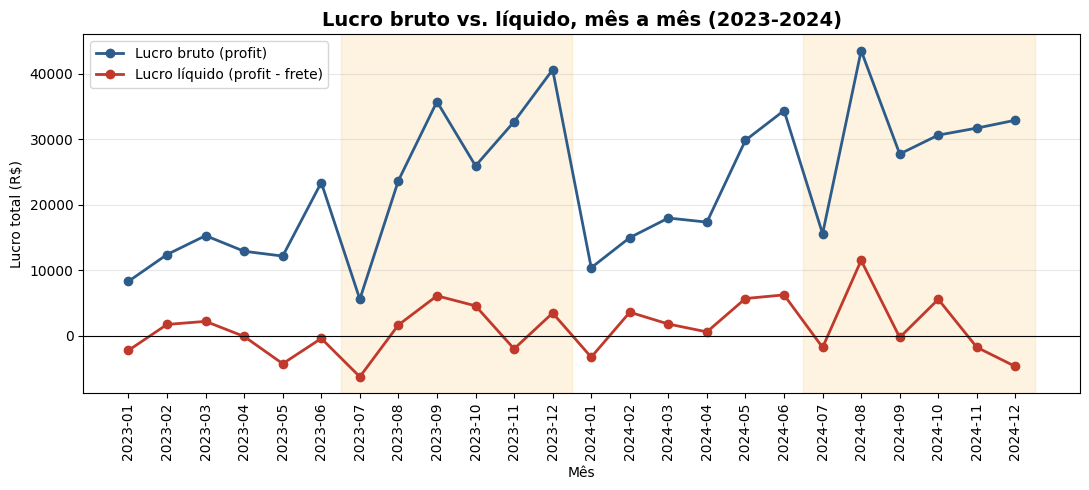

Lucro líquido dez/2023: R$ 3,479.18
Lucro líquido dez/2024: R$ -4,687.38


In [47]:
import matplotlib.pyplot as plt

df_final['order_date_dt'] = pd.to_datetime(df_final['order_date'], errors='coerce', utc=True)
df_final['mes'] = df_final['order_date_dt'].dt.to_period('M').astype(str)

# Revisão pós-validação com o Gem: o gráfico original só mostrava profit (bruto), o que mascarava
# a queda real depois do frete — agora as duas linhas aparecem juntas, como ele recomendou.
tendencia_mensal = df_final.groupby('mes').agg(lucro_bruto=('profit', 'sum'), frete=('shipping_cost', 'sum'))
tendencia_mensal['lucro_liquido'] = tendencia_mensal['lucro_bruto'] - tendencia_mensal['frete']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tendencia_mensal.index, tendencia_mensal['lucro_bruto'], marker='o', color='#2E5C8A',
        linewidth=2, label='Lucro bruto (profit)')
ax.plot(tendencia_mensal.index, tendencia_mensal['lucro_liquido'], marker='o', color='#C0392B',
        linewidth=2, label='Lucro líquido (profit - frete)')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvspan(5.5, 11.5, color='#F4A300', alpha=0.12)
ax.axvspan(17.5, 23.5, color='#F4A300', alpha=0.12)
ax.set_title('Lucro bruto vs. líquido, mês a mês (2023-2024)', fontsize=14, weight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Lucro total (R$)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_tendencia_lucro_mensal.png', dpi=150)
plt.show()

print(f"Lucro líquido dez/2023: R$ {tendencia_mensal.loc['2023-12', 'lucro_liquido']:,.2f}")
print(f"Lucro líquido dez/2024: R$ {tendencia_mensal.loc['2024-12', 'lucro_liquido']:,.2f}")

**Insight principal (revisado após feedback crítico do Gem):** a versão original deste gráfico
só mostrava `profit` — e isso escondia o problema real. Com as duas linhas juntas, fica visível que
a distância entre bruto e líquido cresce exatamente nos meses de pico de vendas: dez/2023 parecia
um mês de R$40,6k de lucro, mas o líquido real foi de apenas **R$3.479,18**; dez/2024, que teve
R$32,9k de lucro bruto, fechou **negativo em -R$4.687,38** depois do frete. A diretoria não pode
comemorar o pico de fim de ano olhando só a linha azul — é exatamente nesses meses que o frete mais
corrói o resultado.

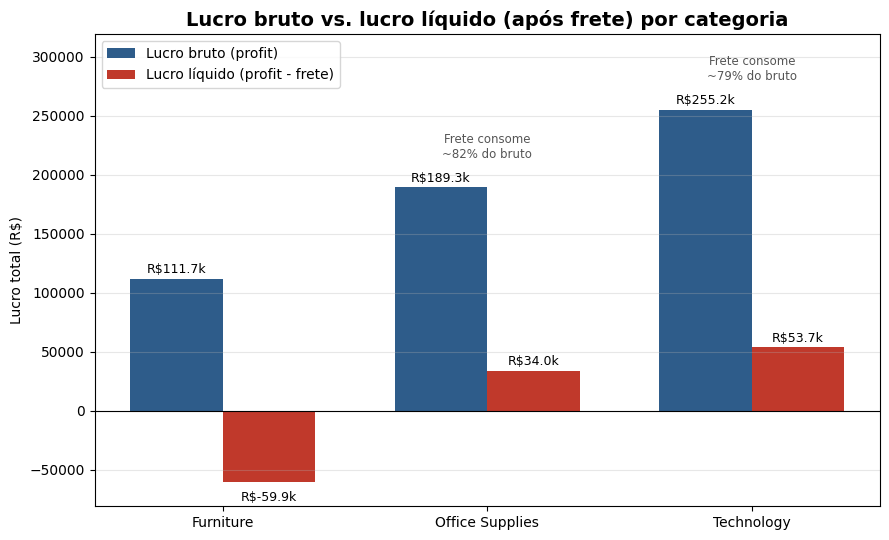

In [48]:
lucro_por_categoria = df_final.groupby('category').agg(
    lucro_bruto=('profit', 'sum'),
    frete_total=('shipping_cost', 'sum')
)
lucro_por_categoria['lucro_liquido'] = lucro_por_categoria['lucro_bruto'] - lucro_por_categoria['frete_total']
lucro_por_categoria['frete_pct_bruto'] = 100 * lucro_por_categoria['frete_total'] / lucro_por_categoria['lucro_bruto']

fig, ax = plt.subplots(figsize=(9, 5.5))
x = range(len(lucro_por_categoria))
largura = 0.35
barras_bruto = ax.bar([i - largura/2 for i in x], lucro_por_categoria['lucro_bruto'], largura,
                       label='Lucro bruto (profit)', color='#2E5C8A')
barras_liquido = ax.bar([i + largura/2 for i in x], lucro_por_categoria['lucro_liquido'], largura,
                         label='Lucro líquido (profit - frete)', color='#C0392B')

# Rótulos com valor exato sobre cada barra, como pedido no feedback do Gem
for barra in barras_bruto:
    altura = barra.get_height()
    ax.annotate(f'R${altura/1000:,.1f}k', (barra.get_x() + barra.get_width()/2, altura),
                textcoords="offset points", xytext=(0, 4), ha='center', fontsize=9)
for barra in barras_liquido:
    altura = barra.get_height()
    deslocamento = 4 if altura >= 0 else -14
    ax.annotate(f'R${altura/1000:,.1f}k', (barra.get_x() + barra.get_width()/2, altura),
                textcoords="offset points", xytext=(0, deslocamento), ha='center', fontsize=9)

# Anotação de retenção de margem para Office Supplies e Technology, pra não parecerem "seguras"
for i, cat in enumerate(lucro_por_categoria.index):
    if cat != 'Furniture':
        pct = lucro_por_categoria.loc[cat, 'frete_pct_bruto']
        ax.annotate(f'Frete consome\n~{pct:.0f}% do bruto', xy=(i, lucro_por_categoria.loc[cat, 'lucro_bruto']),
                    xytext=(i, lucro_por_categoria.loc[cat, 'lucro_bruto'] + 25000),
                    ha='center', fontsize=8.5, color='#555555')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(lucro_por_categoria.index)
ax.set_title('Lucro bruto vs. lucro líquido (após frete) por categoria', fontsize=14, weight='bold')
ax.set_ylabel('Lucro total (R$)')
ax.set_ylim(bottom=lucro_por_categoria['lucro_liquido'].min() * 1.35, top=lucro_por_categoria['lucro_bruto'].max() * 1.25)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_lucro_bruto_vs_liquido.png', dpi=150)
plt.show()

**Insight principal (revisado após feedback crítico do Gem):** com rótulos e anotação, o
gráfico agora impede a leitura errada que ele apontou — que Office Supplies e Technology estariam
"seguras" só porque ficam no azul. As anotações deixam explícito que o frete consome ~82% do lucro
bruto de Office Supplies e ~79% do de Technology — `Furniture` é o caso mais grave (vira prejuízo),
mas o problema de custo logístico é sistêmico nas 3 categorias, não exclusivo de uma.

**Prompt de validação usado com o Gem:**
> "Aqui está a descrição dos meus dois gráficos: (1) linha do lucro mensal em 2023-2024, com pico
> em set-dez nos dois anos; (2) barras comparando lucro bruto e lucro líquido (após frete) por
> categoria, onde Furniture vira negativo e as outras duas seguem positivas. Dê um feedback
> crítico: esses gráficos estão fáceis de ler? Existe alguma conclusão errônea que alguém poderia
> tirar deles?"

**Resposta do Gem e correções aplicadas:** ele identificou dois problemas reais — (1) o Gráfico 1
mostrava só lucro bruto, mascarando que dez/2024 na verdade fechou negativo depois do frete; (2) o
Gráfico 2 podia sugerir que Office Supplies/Technology estavam "seguras". As duas versões acima já
incorporam a correção: linha dupla no Gráfico 1, rótulos e anotação de retenção de margem no
Gráfico 2. Um dos números que ele deu (lucro líquido de dez/2023 e dez/2024) veio ligeiramente
impreciso (off por ~R$0,1k) — a crítica em si estava certa, mas usei o valor recalculado, não o
dele, no gráfico final.